In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

# Load the feature-engineered dataset
df = pd.read_csv('../data/features/features_ready.csv')
df.shape


C:\Users\aditi\AppData\Local\Temp\ipykernel_19976\4015341732.py:8: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/features/features_ready.csv')


(26759, 34)

In [2]:
df.head()


,raceId,year,circuitId,driverId,driver_name,constructorId,constructor_name,grid,positionOrder,points,...,points_per_race,podium_count,dnf_flag,constructor_dnf_rate,constructor_avg_points,synergy,rolling_points_driver,win,circuit_win_ratio,positionClass
0,18,2008,1,1,Lewis Hamilton,1,McLaren,1,1,10.0,...,10.0,0,False,0.0,4.194444,8.300000,10.0,1,1.0,1
1,18,2008,1,2,Nick Heidfeld,2,BMW Sauber,5,2,8.0,...,8.0,0,False,0.0,3.750000,2.328571,8.0,0,0.0,2
2,18,2008,1,3,Nico Rosberg,3,Williams,7,3,6.0,...,6.0,0,False,0.0,0.722222,1.078571,6.0,0,0.0,3
3,18,2008,1,4,Fernando Alonso,4,Renault,11,4,5.0,...,5.0,0,False,0.0,2.222222,4.415094,5.0,0,0.0,0
4,18,2008,1,5,Heikki Kovalainen,1,McLaren,3,5,4.0,...,4.0,0,False,0.0,4.194444,2.142857,4.0,0,0.0,0


In [3]:
missing = df.isnull().mean().sort_values(ascending=False)
missing[missing > 0]


Series([], dtype: float64)

In [4]:
fig = px.histogram(df, x='positionOrder', nbins=30, title='Finishing Position Distribution')
fig.show()


In [5]:
top_teams = df[df['podium'] == 1]['constructor_name'].value_counts().head(10).reset_index()
top_teams.columns = ['constructor_name', 'podium_count']

fig = px.bar(top_teams, x='constructor_name', y='podium_count', title='Top 10 Constructors by Podium Finishes')
fig.show()


In [6]:
top_drivers = df.groupby('driver_name')['points'].sum().sort_values(ascending=False).head(10).reset_index()

fig = px.bar(top_drivers, x='driver_name', y='points', title='Top 10 Drivers by Total Career Points')
fig.show()


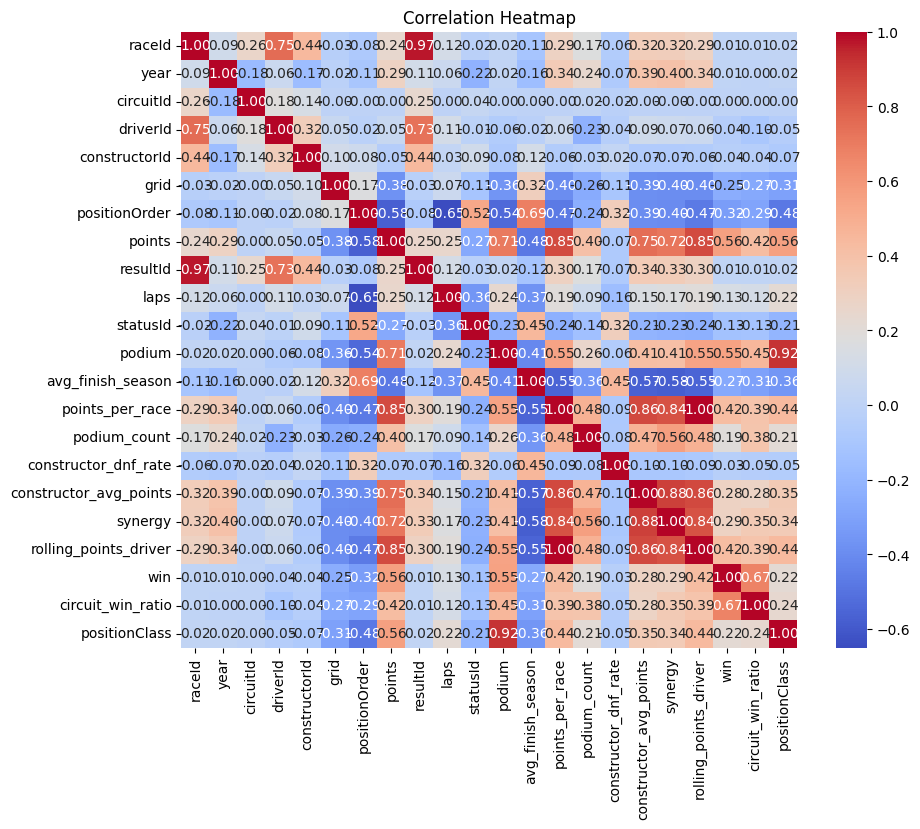

In [7]:
numeric_cols = df.select_dtypes(include='number')
corr = numeric_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Heatmap')
plt.show()
